<a href="https://colab.research.google.com/github/kaansoftware34/softito_calismalar_face2face/blob/main/LSTM_Detailed_ipynb_150626_zaman_serisi_ornek.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔐 LSTM — Satır Satır, Kelime Kelime Açıklamalı Rehber

Her kod bloğu **neden yazıldığı**, **ne anlama geldiği** ve **içeride ne olduğu**  
açısından detaylıca anlatılmıştır.

| Bölüm | İçerik |
|-------|--------|
| **1** | Kütüphaneler — her import neden var? |
| **2** | Sigmoid & tanh — matematikten koda |
| **3** | VanillaLSTMCell — 4 kapı satır satır |
| **4** | Kapı görselleştirmesi |
| **5** | PyTorch LSTMClassifier — katman katman |
| **6** | Eğitim döngüsü — her satır açıklamalı |
| **7** | RNN vs LSTM gradient karşılaştırması |
| **8** | Zaman serisi tahmini |
| **9** | Eğitilmiş kapıları okuma |
| **10** | Özet |


---
## 📦 Bölüm 1 — Kütüphaneler: Her Import Neden Var?


In [5]:
# numpy: sayısal hesaplamalar — matris çarpımı, tanh, exp vb.
# Sıfırdan LSTM'yi numpy ile yazacağız: PyTorch'un içinde ne olduğunu görmek için.
import numpy as np

# torch: derin öğrenme — otomatik türev (autograd) + GPU desteği
import torch

# torch.nn: hazır katmanlar — nn.LSTM, nn.Linear, nn.Dropout
import torch.nn as nn

# torch.optim: optimizörler — Adam, SGD, RMSProp
# Ağırlıkları güncellemek için kullanılır.
import torch.optim as optim

# matplotlib: grafik çizimi
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Tekrarlanabilirlik: sabit tohum → her çalışmada aynı sonuç
np.random.seed(42)
torch.manual_seed(42)

print("✓ NumPy  :", np.__version__)
print("✓ PyTorch:", torch.__version__)
print()
print("numpy   → sıfırdan LSTM için matematiksel işlemler")
print("torch   → PyTorch modeli, eğitim ve GPU desteği")
print("matplotlib → tüm grafikler")


✓ NumPy  : 2.0.2
✓ PyTorch: 2.11.0+cpu

numpy   → sıfırdan LSTM için matematiksel işlemler
torch   → PyTorch modeli, eğitim ve GPU desteği
matplotlib → tüm grafikler


---
## 📐 Bölüm 2 — Aktivasyon Fonksiyonları: Sigmoid ve tanh

LSTM'de iki farklı aktivasyon kullanılır — her birinin farklı bir amacı var.

| Fonksiyon | Aralık | Kullanım |
|-----------|--------|---------|
| `sigmoid` | [0, 1] | Kapılar — "ne kadar geçsin?" |
| `tanh`    | [-1, 1] | Aday değer — "ne yönde, ne kadar?" |


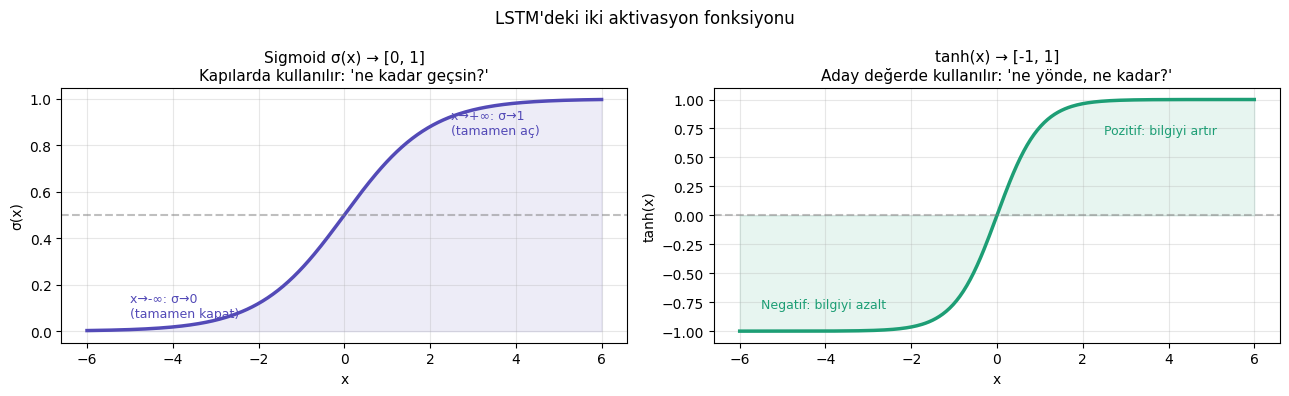

Türev karşılaştırması (gradient akışı açısından kritik):
  sigmoid max türevi : 0.250  (x=0'da)
  tanh    max türevi : 1.000  (x=0'da)

RNN'de zincir: tanh' × tanh' × ... → her adımda ≤0.25 ile çarpılır → hızla sıfır
LSTM'de c_t : gradient sadece f_t ile çarpılır → f_t≈1 ise neredeyse sıfırlanmaz


In [6]:
def sigmoid(x):
    """
    σ(x) = 1 / (1 + e^{-x})

    np.clip(x, -500, 500) neden?
    → x=-1000 için e^1000 → sonsuz (overflow).
    → clip ile sınırlandırıyoruz: bu aralıkta sigmoid zaten 0 veya 1'e çok yakın,
      sayısal sonuç değişmez ama hesap kararlı kalır.
    """
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))


# Grafik
x = np.linspace(-6, 6, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(x, sigmoid(x), color="#534AB7", linewidth=2.5)
axes[0].axhline(0.5, color="gray", linestyle="--", alpha=0.5)
axes[0].fill_between(x, sigmoid(x), alpha=0.1, color="#534AB7")
axes[0].set_title("Sigmoid σ(x) → [0, 1]\nKapılarda kullanılır: 'ne kadar geçsin?'", fontsize=11)
axes[0].set_xlabel("x"); axes[0].set_ylabel("σ(x)"); axes[0].grid(alpha=0.3)
axes[0].annotate("x→-∞: σ→0\n(tamamen kapat)", xy=(-5, 0.06), fontsize=9, color="#534AB7")
axes[0].annotate("x→+∞: σ→1\n(tamamen aç)",   xy=(2.5, 0.85), fontsize=9, color="#534AB7")

axes[1].plot(x, np.tanh(x), color="#1D9E75", linewidth=2.5)
axes[1].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[1].fill_between(x, np.tanh(x), alpha=0.1, color="#1D9E75")
axes[1].set_title("tanh(x) → [-1, 1]\nAday değerde kullanılır: 'ne yönde, ne kadar?'", fontsize=11)
axes[1].set_xlabel("x"); axes[1].set_ylabel("tanh(x)"); axes[1].grid(alpha=0.3)
axes[1].annotate("Negatif: bilgiyi azalt", xy=(-5.5, -0.8), fontsize=9, color="#1D9E75")
axes[1].annotate("Pozitif: bilgiyi artır",  xy=(2.5,  0.7),  fontsize=9, color="#1D9E75")

plt.suptitle("LSTM'deki iki aktivasyon fonksiyonu", fontsize=12)
plt.tight_layout()
plt.savefig("/tmp/activations.png", dpi=120, bbox_inches="tight")
plt.show()

print("Türev karşılaştırması (gradient akışı açısından kritik):")
print(f"  sigmoid max türevi : {sigmoid(0)*(1-sigmoid(0)):.3f}  (x=0'da)")
print(f"  tanh    max türevi : {1-np.tanh(0)**2:.3f}  (x=0'da)")
print()
print("RNN'de zincir: tanh' × tanh' × ... → her adımda ≤0.25 ile çarpılır → hızla sıfır")
print("LSTM'de c_t : gradient sadece f_t ile çarpılır → f_t≈1 ise neredeyse sıfırlanmaz")


---
## 🔬 Bölüm 3 — VanillaLSTMCell: Tüm Sınıf Satır Satır

Tüm LSTM hücresi tek bir blokta tanımlanmıştır.  
Her bölüm yorum satırlarıyla ayrıntılı açıklanmıştır.


In [7]:
class VanillaLSTMCell:
    """
    Tek bir LSTM hücresi — sıfırdan, sadece NumPy ile.
    PyTorch kullanmaz: formülün tam olarak ne yaptığını görmek için.

    İki durum taşır:
        h : gizli durum (hidden state)  — kısa vadeli hafıza
        c : hücre durumu (cell state)   — uzun vadeli hafıza
    """

    # ─── __init__: ağırlıkları başlat ────────────────────────────────────
    def __init__(self, input_size: int, hidden_size: int):
        """
        Parametreler:
            input_size  (D): her zaman adımındaki girdi boyutu
            hidden_size (H): gizli/hücre durumu boyutu

        Neden küçük başlangıç (scale=0.1)?
        → Büyük değerler sigmoid/tanh'ı doygunluğa sokar
          → gradient sıfıra düşer → model öğrenemez.
        → 0.1 ile başlayınca gradyanlar sağlıklı akar.

        Neden [h_{t-1}, x_t] birleştirilir?
        → Her kapı hem geçmişe (h) hem mevcut girdiye (x) bakmalı.
        → Birleştirince tek matris çarpımı yeterli:
          W · [h, x] = W_h·h + W_x·x
        → W şekli: (H, H+D) — hem h hem x'i kapsıyor
        """
        rng   = np.random.default_rng(42)
        H, D  = hidden_size, input_size
        scale = 0.1

        # ── 4 Kapı Ağırlık Matrisleri (H, H+D) ──────────────────────────
        # Unutma kapısı: c_{t-1}'den ne kadar geçsin?  0=sil 1=koru
        self.W_f = rng.standard_normal((H, H + D)) * scale

        # Giriş kapısı: yeni bilgiden ne kadar eklensin?  0=ekleme 1=ekle
        self.W_i = rng.standard_normal((H, H + D)) * scale

        # Aday değer: eklenecek ham bilgi  [-1,1] arası  tanh kullanır
        self.W_g = rng.standard_normal((H, H + D)) * scale

        # Çıkış kapısı: hücreden ne kadar çıksın?  0=gizle 1=göster
        self.W_o = rng.standard_normal((H, H + D)) * scale

        # ── Bias Vektörleri (H,) ─────────────────────────────────────────
        # Unutma biası neden 1.0 (diğerleri 0)?
        # → Eğitim başında modelin "unut" kararı vermesini istemiyoruz.
        # → b_f=1 → sigmoid(... + 1) ≈ 0.73 → başlangıçta hafızayı koru.
        # → Uygulama trick'i: eğitimi hızlandırır.
        self.b_f = np.ones(H)    # ← sadece bu 1, diğerleri sıfır
        self.b_i = np.zeros(H)
        self.b_g = np.zeros(H)
        self.b_o = np.zeros(H)

        self.hidden_size = H
        self.input_size  = D

    # ─── Yardımcı: iki vektörü birleştir ────────────────────────────────
    def _concat(self, h_prev, x_t):
        """
        h_prev (H,) + x_t (D,) → combined (H+D,)

        np.concatenate: iki diziyi arka arkaya ekler.
        Örnek: h=[0.1,-0.3] x=[0.5,0.2,-0.1] → [0.1,-0.3,0.5,0.2,-0.1]
        """
        return np.concatenate([h_prev, x_t])

    # ─── KAPI 1: Unutma Kapısı ───────────────────────────────────────────
    def forget_gate(self, combined):
        """
        f_t = σ( W_f · combined + b_f )   → [0,1]^H

        SORU: c_{t-1}'den (eski hafıza) ne kadar tutalım?
          f_t[j]=0 → j. boyuttaki eski hafızayı TAMAMEN SİL
          f_t[j]=1 → j. boyuttaki eski hafızayı AYNEN KORU

        Gerçek örnek: "Ali doktordur. Ali [yeni kişi] mühendistir."
        → 'Ali' değişince eski mesleği unutmak gerekir.
        → Unutma kapısı bunu öğrenir.

        W_f @ combined: (H, H+D) @ (H+D,) → (H,)  matris-vektör çarpımı
        + b_f         : (H,) + (H,) → (H,)          bias ekle
        sigmoid(...)  : (H,) → (H,)  her eleman [0,1]'e sıkıştır
        """
        return sigmoid(self.W_f @ combined + self.b_f)

    # ─── KAPI 2: Giriş Kapısı ────────────────────────────────────────────
    def input_gate(self, combined):
        """
        i_t = σ( W_i · combined + b_i )   → [0,1]^H

        SORU: Aday değerden (g_t) ne kadarını ekleyelim?
          i_t[j]=0 → bu güncellemeyi YOKSAY
          i_t[j]=1 → bu güncellemeyi KABUL ET

        Sezgi: i_t 'ne kadar dikkat et?' — g_t 'ne öğrenmek istiyorum?'
        Hücre güncellemesi: i_t ⊙ g_t = 'filtrelenmiş öğrenme'
        """
        return sigmoid(self.W_i @ combined + self.b_i)

    # ─── KAPI 3: Aday Değer ──────────────────────────────────────────────
    def candidate(self, combined):
        """
        g_t = tanh( W_g · combined + b_g )   → [-1,1]^H

        NOT: Teknik olarak 'kapı' değil — sigmoid değil tanh kullanır.
             Bu yüzden [0,1] değil [-1,1] aralığında.
             'cell gate' veya 'g' olarak anılır.

        Neden tanh?
        → Sigmoid sadece 'ne kadar' sorusunu yanıtlar (0..1).
        → tanh 'ne yönde ve ne kadar' sorusunu yanıtlar (-1..+1).
        → Hücreyi hem artırabilir (+) hem azaltabilir (-).

        Örnek: sıcaklık tahmini için g_t=-0.8 → 'sıcaklık düşüyor' sinyali
        """
        return np.tanh(self.W_g @ combined + self.b_g)

    # ─── KAPI 4: Çıkış Kapısı ────────────────────────────────────────────
    def output_gate(self, combined):
        """
        o_t = σ( W_o · combined + b_o )   → [0,1]^H

        SORU: c_t'nin (tüm uzun hafıza) kaçını h_t'ye yansıtalım?
          o_t[j]=0 → c_t'nin j. boyutunu GİZLE
          o_t[j]=1 → c_t'nin j. boyutunu GÖSTER

        Ardından: h_t = o_t ⊙ tanh(c_t)
        tanh(c_t): hücre durumunu -1..+1'e normalize eder
        o_t      : ne kadarının h_t'ye geçeceğini filtreler
        """
        return sigmoid(self.W_o @ combined + self.b_o)

    # ─── forward_step: TEK ADIM ──────────────────────────────────────────
    def forward_step(self, x_t, h_prev, c_prev):
        """
        Tek bir zaman adımını işler.

        Parametreler:
            x_t    (D,): mevcut adımın girdisi
            h_prev (H,): önceki gizli durum   — kısa hafıza
            c_prev (H,): önceki hücre durumu  — uzun hafıza

        Döndürür:
            h_t  (H,): yeni gizli durum
            c_t  (H,): yeni hücre durumu
            gates dict: kapı değerleri (görselleştirme için)

        Adım adım:
        ① Girdiyi birleştir
        ② Unutma: eski hafızadan ne kalsın?
        ③ Giriş: ne kadar yeni bilgi eklensin?
        ④ Aday: hangi yeni bilgi eklensin?
        ⑤ Çıkış: hücreyi ne kadar göster?
        ⑥ Hücre durumunu güncelle
        ⑦ Gizli durumu güncelle
        """
        # ① Birleştir: (H,) + (D,) → (H+D,)
        combined = self._concat(h_prev, x_t)

        # ② Unutma: f_t ∈ [0,1]^H — "eskiyi ne kadar unut?"
        f_t = self.forget_gate(combined)

        # ③ Giriş: i_t ∈ [0,1]^H — "yeniden ne kadar ekle?"
        i_t = self.input_gate(combined)

        # ④ Aday: g_t ∈ [-1,1]^H — "ne ekleyeceğim?"
        g_t = self.candidate(combined)

        # ⑤ Çıkış: o_t ∈ [0,1]^H — "hücreyi ne kadar göster?"
        o_t = self.output_gate(combined)

        # ⑥ Hücre durumu güncelle
        # c_t = f_t ⊙ c_{t-1}  +  i_t ⊙ g_t
        #       ───────────────    ────────────
        #       eski hafıza        yeni bilgi
        #       (f_t ile filtreli) (i_t ile kapılı)
        #
        # ⊙ = eleman-eleman çarpım (Hadamard product)
        # numpy'da bu sadece * operatörü ile yapılır (matris değil vektör)
        #
        # GRADIENT NEDEN KAYBOLMUYOR?
        # dc_t/dc_{t-1} = f_t  (sadece tek çarpma, tanh zinciri yok!)
        # f_t ≈ 1 ise gradient neredeyse bölünmeden geçer.
        c_t = f_t * c_prev  +  i_t * g_t

        # ⑦ Gizli durum güncelle
        # h_t = o_t ⊙ tanh(c_t)
        # tanh(c_t): hücreyi -1..+1'e normalize et
        # o_t      : 'hangi boyutları dışarı ver?' filtresi
        h_t = o_t * np.tanh(c_t)

        gates = {"f": f_t, "i": i_t, "g": g_t, "o": o_t}
        return h_t, c_t, gates

    # ─── forward_sequence: TAM DİZİ ──────────────────────────────────────
    def forward_sequence(self, X):
        """
        Tam bir diziyi işler — forward_step'i her adım için çağırır.

        Parametre:
            X (seq_len, D): tüm zaman adımlarının girdisi

        Döndürür:
            H (seq_len, H): her adımın gizli durumu
            C (seq_len, H): her adımın hücre durumu
            gates_list    : her adımın kapı değerleri

        Neden .copy()?
        → h ve c her adımda GÜNCELLENİR (aynı nesne).
        → .copy() olmadan listedeki tüm elemanlar son değeri gösterir.
        → .copy() anlık değeri saklar.
        """
        seq_len, _ = X.shape

        # Başlangıç: h_0 = sıfır, c_0 = sıfır
        # 'Model hiçbir şey bilmiyor' anlamına gelir.
        h = np.zeros(self.hidden_size)
        c = np.zeros(self.hidden_size)

        H_list, C_list, gates_list = [], [], []

        for t in range(seq_len):
            x_t  = X[t]                              # t. adım girdisi
            h, c, gates = self.forward_step(x_t, h, c)  # h ve c güncelleniyor
            H_list.append(h.copy())   # anlık değeri kaydet
            C_list.append(c.copy())
            gates_list.append(gates)

        return np.array(H_list), np.array(C_list), gates_list


# ─── Hızlı test ──────────────────────────────────────────────────────────
INPUT_SIZE  = 6
HIDDEN_SIZE = 12
SEQ_LEN     = 10

cell   = VanillaLSTMCell(INPUT_SIZE, HIDDEN_SIZE)
X_test = np.random.randn(SEQ_LEN, INPUT_SIZE)
H_out, C_out, gates_all = cell.forward_sequence(X_test)

print(f"Girdi  X : {X_test.shape}")
print(f"Gizli  H : {H_out.shape}   → her adımın h_t'si")
print(f"Hücre  C : {C_out.shape}   → her adımın c_t'si")
print()
print("İlk 3 adımın kapı ortalamaları:")
for t in range(3):
    g = gates_all[t]
    print(f"  t={t}:  f={g['f'].mean():.3f} (unut)  "
          f"i={g['i'].mean():.3f} (giriş)  "
          f"o={g['o'].mean():.3f} (çıkış)")


Girdi  X : (10, 6)
Gizli  H : (10, 12)   → her adımın h_t'si
Hücre  C : (10, 12)   → her adımın c_t'si

İlk 3 adımın kapı ortalamaları:
  t=0:  f=0.724 (unut)  i=0.499 (giriş)  o=0.494 (çıkış)
  t=1:  f=0.742 (unut)  i=0.504 (giriş)  o=0.486 (çıkış)
  t=2:  f=0.721 (unut)  i=0.495 (giriş)  o=0.509 (çıkış)


---
## 📊 Bölüm 4 — Kapı Görselleştirmesi

4 kapının zaman içindeki aktivasyonları, `h_t` ve `c_t` ısı haritaları.  
`c_t`'nin normu genellikle `h_t`'den büyük olur — uzun hafıza daha fazla bilgi biriktirir.


/tmp/ipykernel_697/2315840393.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


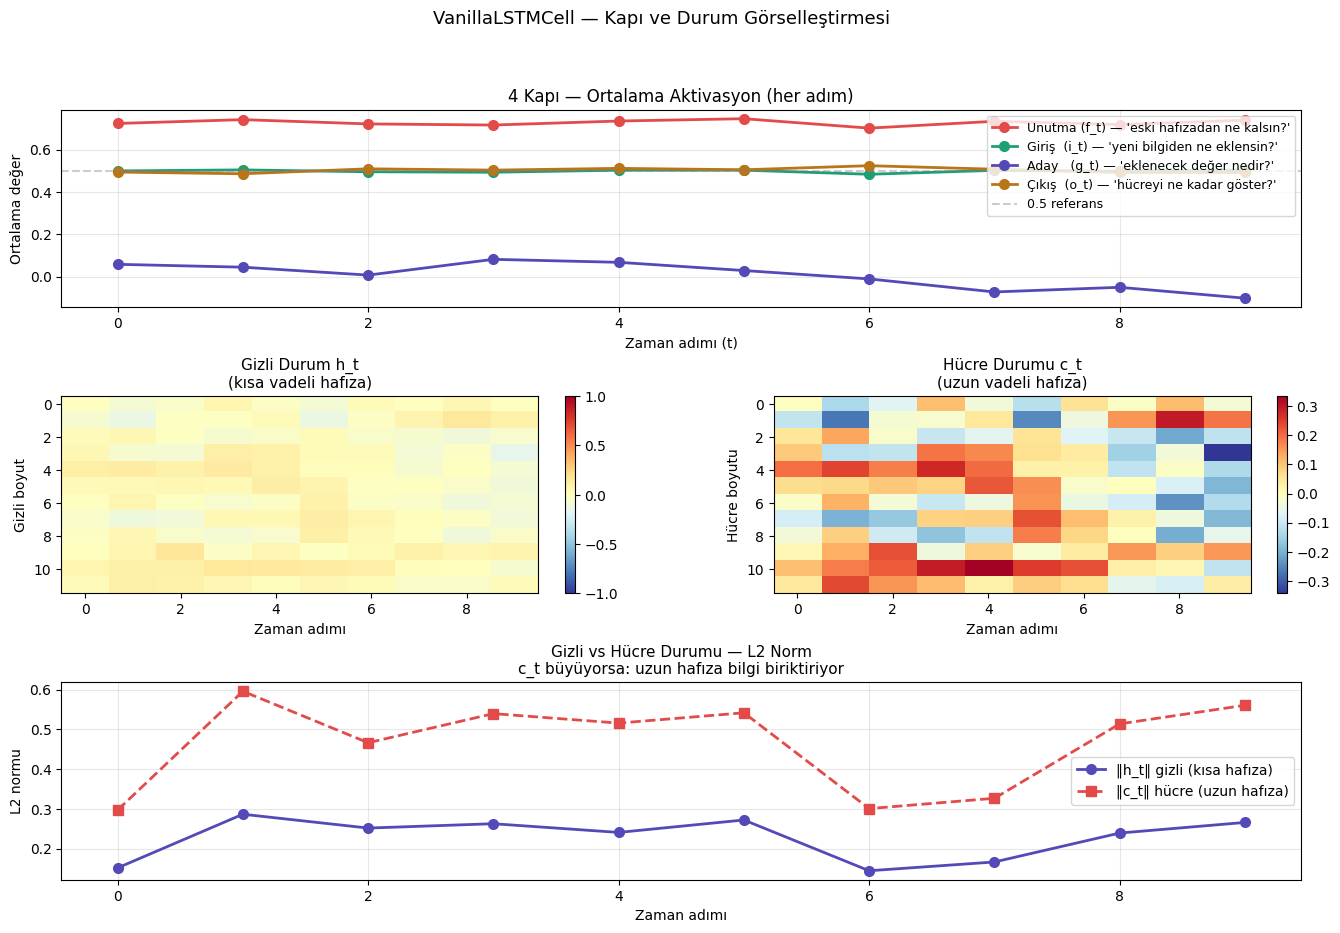

Görselleştirme ✓


In [8]:
gate_means = {k: [] for k in ["f", "i", "g", "o"]}
for step_gates in gates_all:
    for k in gate_means:
        gate_means[k].append(step_gates[k].mean())

fig = plt.figure(figsize=(16, 10))
gs  = GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Kapı aktivasyonları zaman içinde ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
colors_g = {"f": "#E24B4A", "i": "#1D9E75", "g": "#534AB7", "o": "#BA7517"}
labels_g = {
    "f": "Unutma (f_t) — 'eski hafızadan ne kalsın?'",
    "i": "Giriş  (i_t) — 'yeni bilgiden ne eklensin?'",
    "g": "Aday   (g_t) — 'eklenecek değer nedir?'",
    "o": "Çıkış  (o_t) — 'hücreyi ne kadar göster?'"
}
for k, vals in gate_means.items():
    ax1.plot(vals, "o-", label=labels_g[k], color=colors_g[k], linewidth=2, markersize=7)
ax1.axhline(0.5, color="gray", linestyle="--", alpha=0.4, label="0.5 referans")
ax1.set_title("4 Kapı — Ortalama Aktivasyon (her adım)", fontsize=12)
ax1.set_xlabel("Zaman adımı (t)"); ax1.set_ylabel("Ortalama değer")
ax1.legend(fontsize=9, loc="upper right"); ax1.grid(alpha=0.3)

# ── h_t ısı haritası ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
im2 = ax2.imshow(H_out.T, aspect="auto", cmap="RdYlBu_r", vmin=-1, vmax=1)
ax2.set_title("Gizli Durum h_t\n(kısa vadeli hafıza)", fontsize=11)
ax2.set_xlabel("Zaman adımı"); ax2.set_ylabel("Gizli boyut")
plt.colorbar(im2, ax=ax2, fraction=0.046)

# ── c_t ısı haritası ─────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
im3 = ax3.imshow(C_out.T, aspect="auto", cmap="RdYlBu_r")
ax3.set_title("Hücre Durumu c_t\n(uzun vadeli hafıza)", fontsize=11)
ax3.set_xlabel("Zaman adımı"); ax3.set_ylabel("Hücre boyutu")
plt.colorbar(im3, ax=ax3, fraction=0.046)

# ── Norm karşılaştırması ──────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, :])
h_norms = [np.linalg.norm(H_out[t]) for t in range(SEQ_LEN)]
c_norms = [np.linalg.norm(C_out[t]) for t in range(SEQ_LEN)]
ax4.plot(h_norms, "o-", label="‖h_t‖ gizli (kısa hafıza)", color="#534AB7", lw=2, ms=7)
ax4.plot(c_norms, "s--", label="‖c_t‖ hücre (uzun hafıza)", color="#E24B4A", lw=2, ms=7)
ax4.set_title("Gizli vs Hücre Durumu — L2 Norm\n"
              "c_t büyüyorsa: uzun hafıza bilgi biriktiriyor", fontsize=11)
ax4.set_xlabel("Zaman adımı"); ax4.set_ylabel("L2 normu")
ax4.legend(fontsize=10); ax4.grid(alpha=0.3)

plt.suptitle("VanillaLSTMCell — Kapı ve Durum Görselleştirmesi", fontsize=13)
plt.tight_layout()
plt.savefig("/tmp/lstm_gates_detail.png", dpi=120, bbox_inches="tight")
plt.show()
print("Görselleştirme ✓")


---
## 🚀 Bölüm 5 — PyTorch `nn.LSTM` ile Sınıflandırıcı

### `nn.LSTM` döndürdüğü değerler

```python
output, (h_n, c_n) = self.lstm(x)
```

| Değişken | Şekil | Açıklama |
|----------|-------|----------|
| `output` | `(batch, seq, hidden)` | Her adımın h_t'si |
| `h_n`    | `(num_layers, batch, hidden)` | Son adımın gizli durumu |
| `c_n`    | `(num_layers, batch, hidden)` | Son adımın hücre durumu |

`nn.RNN`'den tek fark: `(output, h_n)` yerine `(output, (h_n, c_n))` döner.


In [9]:
class LSTMClassifier(nn.Module):
    """
    Dizi → etiket sınıflandırması.
    Mimari: Girdi → LSTM (2 katman) → Dropout → Linear → Sınıf

    nn.Module'den neden kalıtım?
    → PyTorch'a 'bu bir sinir ağıdır' diyoruz.
    → .parameters(), .train(), .eval() metodlarını otomatik kazanıyoruz.
    → model(x) çağrısı otomatik olarak forward(x)'i çalıştırır.
    """

    def __init__(self, input_size, hidden_size, num_classes,
                 num_layers=2, dropout=0.3):
        """
        super().__init__() neden zorunlu?
        → nn.Module'ün __init__'ini çağırır — iç kayıt defterini kurar.
        → Olmadan 'Module not initialized' hatası alırız.
        """
        super().__init__()

        # nn.LSTM parametreleri ────────────────────────────────────────────
        # input_size   : her adımdaki özellik sayısı
        # hidden_size  : LSTM'nin iç boyutu (büyük → kapasite↑, overfit riski↑)
        # num_layers   : yığılmış LSTM — katman 1'in h_t çıktısı katman 2'nin girdisi
        # batch_first  : True → (batch, seq, feat) — daha sezgisel
        #                False → (seq, batch, feat) — PyTorch'un eski varsayılanı
        # dropout      : katmanlar ARASI — son katmana uygulanmaz
        #                num_layers=1 ise 0 olmalı (tek katmanda anlamsız)
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0,
        )

        # nn.Dropout(p): eğitimde nöronların p oranını rastgele sıfırlar.
        # → Model tek bir nörona bağımlı olamaz → genelleme iyileşir.
        # → model.eval() modunda otomatik KAPANIR (test'te etki yok).
        self.dropout = nn.Dropout(dropout)

        # nn.Linear(in, out): tam bağlı katman
        # Son LSTM katmanının h_T'sini (hidden_size,) → (num_classes,) çevirir.
        # Çıktı: 'logit' = ham skor (softmax uygulanmamış)
        # CrossEntropyLoss içeride softmax yapar, biz yapmıyoruz.
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        """
        İleri geçiş — model(x) çağrısında otomatik çalışır.

        x : (batch_size, seq_len, input_size)

        PyTorch autograd bu fonksiyonun her işlemini izler.
        backward() çağrısında tüm türevler otomatik hesaplanır.
        """
        # LSTM çalıştır
        # output : (batch, seq_len, hidden) — her adımın h_t'si
        # h_n    : (num_layers, batch, hidden) — son gizli durum
        # c_n    : (num_layers, batch, hidden) — son hücre durumu
        output, (h_n, c_n) = self.lstm(x)

        # h_n[-1]: son LSTM katmanının son zaman adımındaki durumu
        # Bu vektör tüm diziyi 'özetler'.
        # Şekil: (batch, hidden_size)
        last_hidden = h_n[-1]

        # Dropout (sadece eğitimde aktif)
        last_hidden = self.dropout(last_hidden)

        # Sınıf skorları: (batch, hidden) → (batch, num_classes)
        logits = self.fc(last_hidden)
        return logits

    def get_all_hidden(self, x):
        """Tüm adımların h_t'sini döndür (analiz için)."""
        with torch.no_grad():
            output, (h_n, c_n) = self.lstm(x)
        return output, h_n, c_n


# Model oluştur ve parametre sayısını incele
model_clf = LSTMClassifier(input_size=10, hidden_size=64,
                            num_classes=3, num_layers=2, dropout=0.3)
print(model_clf)
print()

for name, param in model_clf.named_parameters():
    print(f"  {name:35s}  şekil={str(tuple(param.shape)):20s}  "
          f"{param.numel():>8,} parametre")

total = sum(p.numel() for p in model_clf.parameters())
print(f"\n  TOPLAM: {total:,} parametre")
print()
print("LSTM parametre formülü: 4 × H × (H + D) + 4 × H")
H, D = 64, 10
print(f"  = 4 × {H} × ({H} + {D}) + 4 × {H} = {4*H*(H+D)+4*H:,}  (1. katman)")


LSTMClassifier(
  (lstm): LSTM(10, 64, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)

  lstm.weight_ih_l0                    şekil=(256, 10)                2,560 parametre
  lstm.weight_hh_l0                    şekil=(256, 64)               16,384 parametre
  lstm.bias_ih_l0                      şekil=(256,)                     256 parametre
  lstm.bias_hh_l0                      şekil=(256,)                     256 parametre
  lstm.weight_ih_l1                    şekil=(256, 64)               16,384 parametre
  lstm.weight_hh_l1                    şekil=(256, 64)               16,384 parametre
  lstm.bias_ih_l1                      şekil=(256,)                     256 parametre
  lstm.bias_hh_l1                      şekil=(256,)                     256 parametre
  fc.weight                            şekil=(3, 64)                    192 parametre
  fc.bias                             

---
## 🔄 Bölüm 6 — Eğitim Döngüsü: Her Satır Açıklamalı

```
Her epoch:
① model.train()         → Dropout aktif
② zero_grad()           → Eski gradyanları sil
③ model(X)              → İleri geçiş (BPTT dahil)
④ criterion(logits, y)  → Kayıp hesapla
⑤ loss.backward()       → Geri yayılım: tüm ∂loss/∂param hesaplanır
⑥ clip_grad_norm_()     → Patlayan gradient önlemi
⑦ optimizer.step()      → Ağırlıkları güncelle: param -= lr × grad
⑧ scheduler.step()      → Learning rate'i azalt
```


 Epoch     Kayıp    Doğruluk            LR
──────────────────────────────────────────────
    10    1.0128       46.9%      0.005000
    20    0.8040       62.5%      0.002500
    30    0.6738       69.5%      0.002500
    40    0.4147       85.2%      0.001250
    50    0.2836       91.4%      0.001250
    60    0.2170       93.0%      0.000625
    70    0.1728       93.8%      0.000625
    80    0.1372       95.3%      0.000313

Eğitim tamamlandı ✓


/tmp/ipykernel_697/1607736910.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


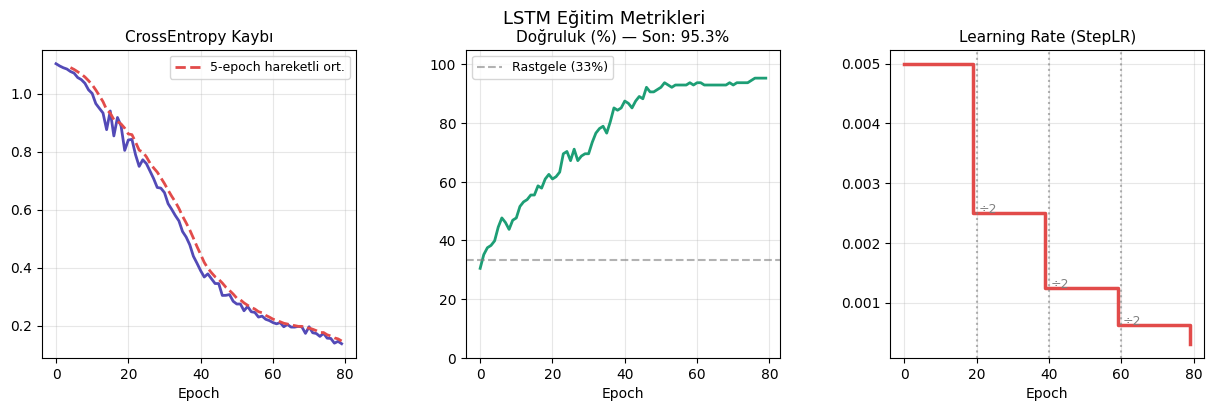

In [10]:
BATCH, SEQ_LEN, IN_SIZE = 128, 50, 10
HID_SIZE, N_CLASSES     = 64, 3
EPOCHS, LR              = 80, 5e-3

# Sentetik veri — rastgele girdi ve etiket
X_train = torch.randn(BATCH, SEQ_LEN, IN_SIZE)
y_train = torch.randint(0, N_CLASSES, (BATCH,))

model_lstm = LSTMClassifier(IN_SIZE, HID_SIZE, N_CLASSES)

# CrossEntropyLoss: çok sınıflı standart kayıp
# İçeride: softmax → log → negatif log likelihood
# L = -log( exp(logit[gerçek]) / Σ exp(logit[i]) )
criterion = nn.CrossEntropyLoss()

# Adam: her parametre için adaptif learning rate
# weight_decay=1e-4: L2 regularization — büyük ağırlıkları cezalandır
optimizer = optim.Adam(model_lstm.parameters(), lr=LR, weight_decay=1e-4)

# StepLR: her 20 epoch'ta lr'yi gamma=0.5 ile çarp (yarıya indir)
# epoch 0-19: 0.005 → epoch 20-39: 0.0025 → epoch 40-59: 0.00125 ...
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

history = {"loss": [], "acc": [], "lr": []}
print(f"{'Epoch':>6}  {'Kayıp':>8}  {'Doğruluk':>10}  {'LR':>12}")
print("─" * 46)

for epoch in range(1, EPOCHS + 1):

    # ① model.train(): Dropout ve BatchNorm'u aktif et
    #    model.eval()'den sonra eğitime dönünce MUTLAKA çağrılmalı
    model_lstm.train()

    # ② Gradyanları sıfırla
    #    PyTorch varsayılan olarak gradyanları BİRİKTİRİR.
    #    Sıfırlamazsak önceki adımın gradyanları eklenir → yanlış güncelleme.
    optimizer.zero_grad()

    # ③ İleri geçiş
    #    Bu satır computation graph oluşturur.
    #    PyTorch her işlemi kaydeder: backward() için.
    logits = model_lstm(X_train)   # (BATCH, N_CLASSES)

    # ④ Kayıp hesapla
    #    logits: (128, 3) raw skorlar
    #    y_train: (128,) gerçek sınıf indeksleri
    loss = criterion(logits, y_train)

    # ⑤ Geri yayılım (BPTT — Backpropagation Through Time)
    #    Zincir kuralıyla her parametrenin ∂loss/∂param değerini hesaplar.
    #    LSTM için gradient zaman boyunca geriye taşınır.
    loss.backward()

    # ⑥ Gradient kırpma
    #    Tüm parametrelerin gradient vektörünün L2 normu max_norm'u aşarsa
    #    ölçekler: grad = grad × (max_norm / ‖grad‖)
    #    Örnek: norm=10, max_norm=1 → tüm gradyanlar 10'a bölünür.
    #    LSTM eğitiminde stabilite için kritik.
    nn.utils.clip_grad_norm_(model_lstm.parameters(), max_norm=1.0)

    # ⑦ Ağırlıkları güncelle
    #    Adam: param = param - lr × m̂ / (√v̂ + ε)
    #    m̂: gradyan hareketli ortalaması (momentum)
    #    v̂: gradyan kare hareketli ortalaması (adaptif ölçekleme)
    optimizer.step()

    # ⑧ Learning rate scheduler
    scheduler.step()

    # Doğruluk hesapla (gradient izlemeden)
    with torch.no_grad():
        preds = logits.argmax(dim=1)   # en yüksek skor → tahmin
        acc   = (preds == y_train).float().mean().item() * 100

    current_lr = scheduler.get_last_lr()[0]
    history["loss"].append(loss.item())
    history["acc"].append(acc)
    history["lr"].append(current_lr)

    if epoch % 10 == 0:
        print(f"{epoch:>6}  {loss.item():>8.4f}  {acc:>9.1f}%  {current_lr:>12.6f}")

print("\nEğitim tamamlandı ✓")

# Eğitim eğrisi
fig = plt.figure(figsize=(15, 4))
gs  = GridSpec(1, 3, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
ax1.plot(history["loss"], color="#534AB7", lw=2)
w = 5
smooth = np.convolve(history["loss"], np.ones(w)/w, mode="valid")
ax1.plot(range(w-1, EPOCHS), smooth, color="#E24B4A", lw=2, ls="--",
         label=f"{w}-epoch hareketli ort.")
ax1.set_title("CrossEntropy Kaybı", fontsize=11); ax1.set_xlabel("Epoch")
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[1])
ax2.plot(history["acc"], color="#1D9E75", lw=2)
ax2.axhline(100/N_CLASSES, color="gray", ls="--", alpha=0.6,
            label=f"Rastgele ({100/N_CLASSES:.0f}%)")
ax2.set_title(f"Doğruluk (%) — Son: {history['acc'][-1]:.1f}%", fontsize=11)
ax2.set_xlabel("Epoch"); ax2.set_ylim(0, 105)
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[2])
ax3.plot(history["lr"], color="#E24B4A", lw=2.5, drawstyle="steps-post")
for step_ep in [20, 40, 60]:
    ax3.axvline(step_ep, color="gray", ls=":", alpha=0.6)
    ax3.annotate("÷2", xy=(step_ep+0.5, history["lr"][step_ep]), fontsize=9, color="gray")
ax3.set_title("Learning Rate (StepLR)", fontsize=11); ax3.set_xlabel("Epoch")
ax3.grid(alpha=0.3)

plt.suptitle("LSTM Eğitim Metrikleri", fontsize=13)
plt.tight_layout()
plt.savefig("/tmp/lstm_training_detail.png", dpi=120, bbox_inches="tight")
plt.show()


---
## ⚡ Bölüm 7 — RNN vs LSTM: Gradient Karşılaştırması

Gradient normu = tüm parametrelerin gradient büyüklüğünün tek bir sayıyla özeti.  
Yüksek varyans veya küçük norm → kaybolan/patlayan gradient problemi.


Kısa dizi (seq=20)...
Uzun dizi (seq=100)...


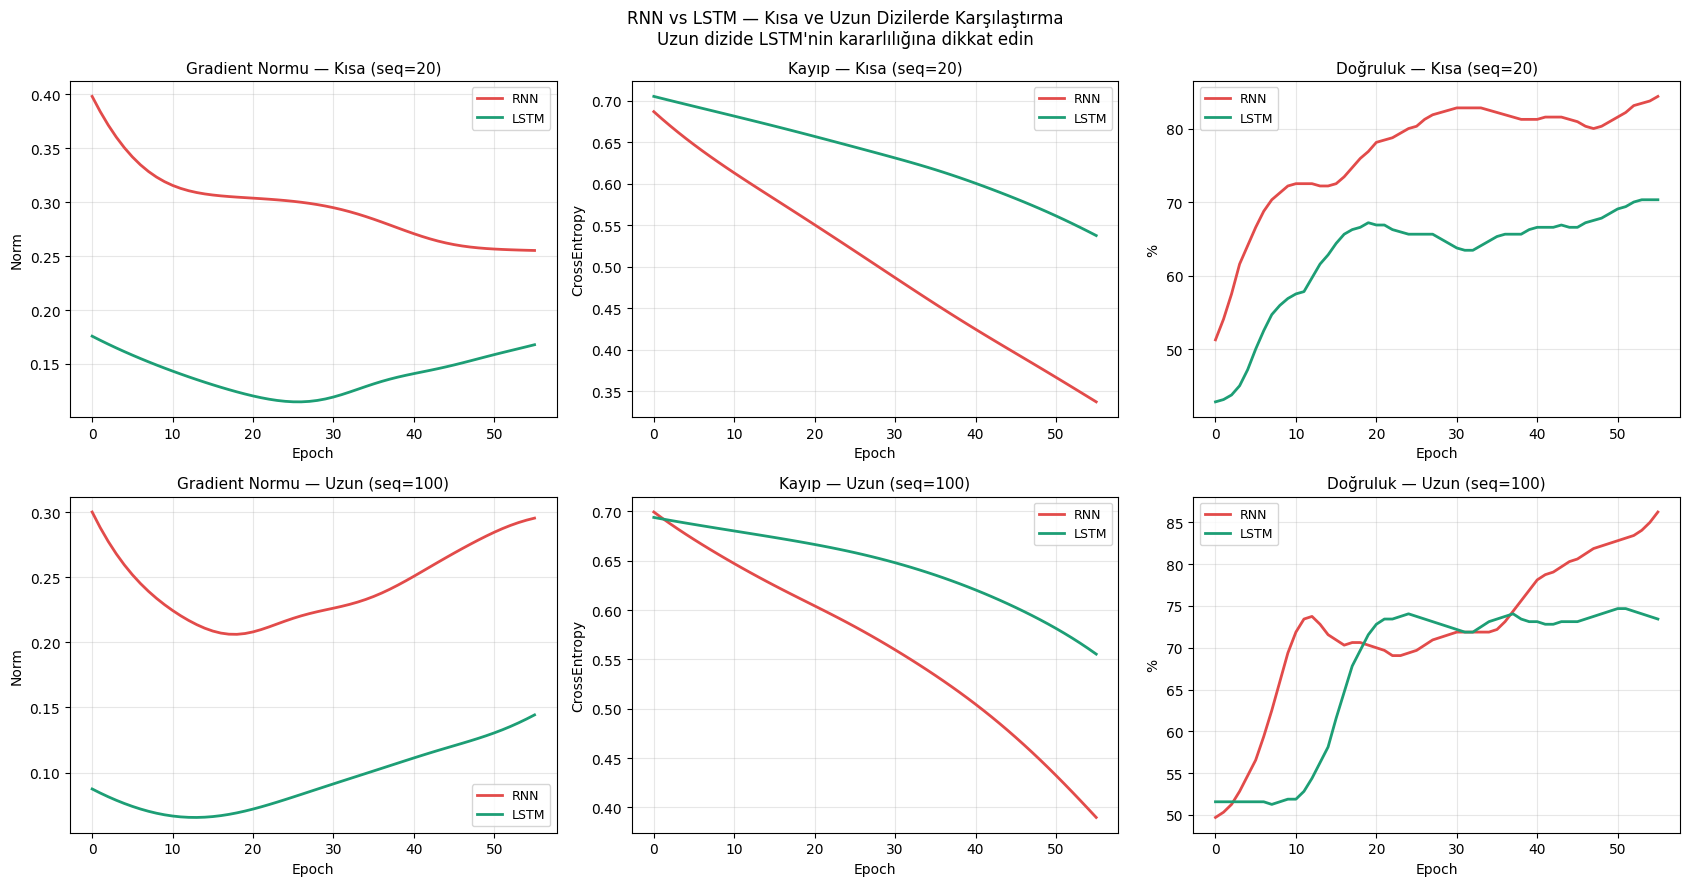

RNN vs LSTM karşılaştırması ✓


In [11]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc  = nn.Linear(hidden_size, num_classes)
    def forward(self, x):
        # nn.RNN: (output, h_n) — hücre durumu yok
        _, h = self.rnn(x)
        return self.fc(h[-1])

class SimpleLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc   = nn.Linear(hidden_size, num_classes)
    def forward(self, x):
        # nn.LSTM: (output, (h_n, c_n)) — c_n'yi yoksay
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])

def train_and_track(ModelClass, seq_len, input_size=8, hidden=32,
                    classes=2, epochs=60, lr=1e-3):
    """
    Modeli eğitir, her epoch'ta gradient normunu kaydeder.

    Gradient normu nasıl hesaplanır?
    → Her parametrenin gradyanını alıp norm karesini toplarız, karekök alırız.
    → Bu, tüm parametrelerdeki gradyanın genel büyüklüğünü verir.
    → Çok küçük veya sıfıra yakınsa: kaybolan gradient
    → Çok büyükse: patlayan gradient
    """
    torch.manual_seed(42)
    X = torch.randn(64, seq_len, input_size)
    y = torch.randint(0, classes, (64,))
    model = ModelClass(input_size, hidden, classes)
    opt   = optim.Adam(model.parameters(), lr=lr)
    crit  = nn.CrossEntropyLoss()

    grad_norms, losses, accs = [], [], []
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        logits = model(X)
        loss   = crit(logits, y)
        loss.backward()

        # Tüm parametre gradyanlarının L2 normu
        # p.grad: backward() sonrası dolu, öncesi None
        total_norm = sum(
            p.grad.norm().item() ** 2
            for p in model.parameters() if p.grad is not None
        ) ** 0.5

        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()

        with torch.no_grad():
            acc = (logits.argmax(1) == y).float().mean().item() * 100
        grad_norms.append(total_norm)
        losses.append(loss.item())
        accs.append(acc)

    return grad_norms, losses, accs

print("Kısa dizi (seq=20)...")
rnn_gn_s,  rnn_l_s,  rnn_a_s  = train_and_track(SimpleRNN,  20)
lstm_gn_s, lstm_l_s, lstm_a_s = train_and_track(SimpleLSTM, 20)
print("Uzun dizi (seq=100)...")
rnn_gn_l,  rnn_l_l,  rnn_a_l  = train_and_track(SimpleRNN,  100)
lstm_gn_l, lstm_l_l, lstm_a_l = train_and_track(SimpleLSTM, 100)

def smooth_arr(vals, w=5):
    return np.convolve(vals, np.ones(w)/w, mode="valid")

fig, axes = plt.subplots(2, 3, figsize=(17, 9))

def pc(ax, rnn, lstm, title, ylabel, w=5):
    ax.plot(smooth_arr(rnn,  w), label="RNN",  color="#E24B4A", lw=2)
    ax.plot(smooth_arr(lstm, w), label="LSTM", color="#1D9E75", lw=2)
    ax.set_title(title, fontsize=11); ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel); ax.legend(fontsize=9); ax.grid(alpha=0.3)

pc(axes[0,0], rnn_gn_s, lstm_gn_s, "Gradient Normu — Kısa (seq=20)",  "Norm")
pc(axes[0,1], rnn_l_s,  lstm_l_s,  "Kayıp — Kısa (seq=20)",            "CrossEntropy")
pc(axes[0,2], rnn_a_s,  lstm_a_s,  "Doğruluk — Kısa (seq=20)",        "%")
pc(axes[1,0], rnn_gn_l, lstm_gn_l, "Gradient Normu — Uzun (seq=100)", "Norm")
pc(axes[1,1], rnn_l_l,  lstm_l_l,  "Kayıp — Uzun (seq=100)",           "CrossEntropy")
pc(axes[1,2], rnn_a_l,  lstm_a_l,  "Doğruluk — Uzun (seq=100)",       "%")

plt.suptitle("RNN vs LSTM — Kısa ve Uzun Dizilerde Karşılaştırma\n"
             "Uzun dizide LSTM'nin kararlılığına dikkat edin", fontsize=12)
plt.tight_layout()
plt.savefig("/tmp/rnn_vs_lstm_detail.png", dpi=120, bbox_inches="tight")
plt.show()
print("RNN vs LSTM karşılaştırması ✓")


---
## 📈 Bölüm 8 — Zaman Serisi Tahmini

### Kayan Pencere (Sliding Window) Mantığı

```
Seri: [a, b, c, d, e, f, ...]
Pencere=3:
  X[0]=[a,b,c] → y[0]=d
  X[1]=[b,c,d] → y[1]=e
  X[2]=[c,d,e] → y[2]=f
```

**Neden zaman serisi karıştırılmaz?**  
Gelecek veri eğitimde kullanılırsa "data leakage" olur — model gerçekte göremeyeceği  
bilgiyi öğrenir ve test sonuçları yanıltıcı derecede iyi görünür.


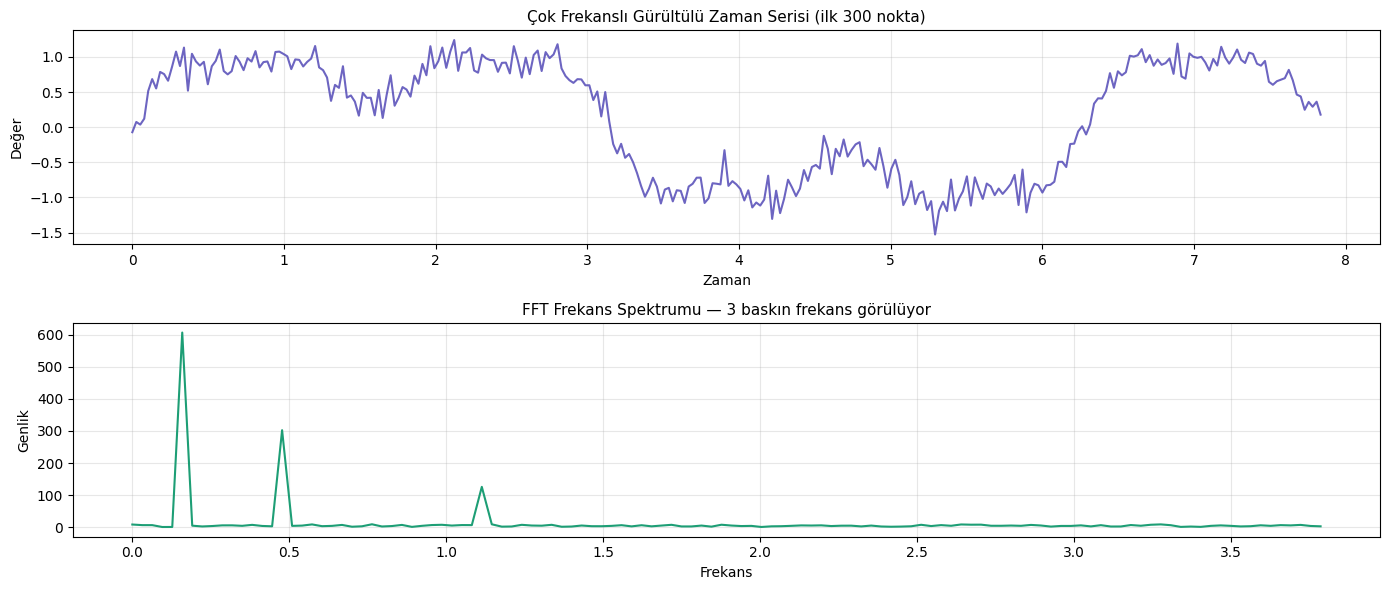

Pencere boyutu : 40
Eğitim: X=torch.Size([928, 40, 1]), y=torch.Size([928])
Test  : X=torch.Size([232, 40, 1]), y=torch.Size([232])

X şekli: (örnek, pencere, 1)
  örnek   : her bir eğitim örneği (pencere-etiket çifti)
  pencere : geçmiş kaç adıma bakıyoruz
  1       : tek özellik (serinin değeri)


In [12]:
# Çok frekanslı sinüs serisi + gürültü
t      = np.linspace(0, 10 * np.pi, 1200)
series = (np.sin(t)
        + 0.5 * np.sin(3 * t)     # harmonik
        + 0.2 * np.sin(7 * t)     # yüksek frekans
        + 0.15 * np.random.randn(len(t)))  # gürültü

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
axes[0].plot(t[:300], series[:300], color="#534AB7", lw=1.5, alpha=0.85)
axes[0].set_title("Çok Frekanslı Gürültülü Zaman Serisi (ilk 300 nokta)", fontsize=11)
axes[0].set_xlabel("Zaman"); axes[0].set_ylabel("Değer"); axes[0].grid(alpha=0.3)

# FFT
fft_v = np.abs(np.fft.rfft(series))
freqs = np.fft.rfftfreq(len(series), d=(t[1]-t[0]))
axes[1].plot(freqs[:120], fft_v[:120], color="#1D9E75", lw=1.5)
axes[1].set_title("FFT Frekans Spektrumu — 3 baskın frekans görülüyor", fontsize=11)
axes[1].set_xlabel("Frekans"); axes[1].set_ylabel("Genlik"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/tmp/timeseries.png", dpi=120, bbox_inches="tight")
plt.show()


def make_sequences(data, window):
    """
    Kayan pencere ile dizi-etiket çiftleri.

    data   : (N,)
    window : pencere boyutu

    Döndürür:
        X : (N-window, window, 1) — .unsqueeze(-1) çünkü nn.LSTM
                                    (batch, seq, features) bekler;
                                    tek özelliğimiz var → features=1
        y : (N-window,)          — bir sonraki değer (regresyon hedefi)
    """
    X_list, y_list = [], []
    for i in range(len(data) - window):
        X_list.append(data[i : i + window])
        y_list.append(data[i + window])
    X_t = torch.tensor(np.array(X_list), dtype=torch.float32).unsqueeze(-1)
    y_t = torch.tensor(np.array(y_list), dtype=torch.float32)
    return X_t, y_t


WINDOW    = 40
X_seq, y_seq = make_sequences(series, WINDOW)
split     = int(0.8 * len(X_seq))
X_tr, X_te = X_seq[:split], X_seq[split:]
y_tr, y_te = y_seq[:split], y_seq[split:]

print(f"Pencere boyutu : {WINDOW}")
print(f"Eğitim: X={X_tr.shape}, y={y_tr.shape}")
print(f"Test  : X={X_te.shape}, y={y_te.shape}")
print()
print("X şekli: (örnek, pencere, 1)")
print("  örnek   : her bir eğitim örneği (pencere-etiket çifti)")
print("  pencere : geçmiş kaç adıma bakıyoruz")
print("  1       : tek özellik (serinin değeri)")


 Epoch           MSE      RMSE
──────────────────────────────
    20      0.033509   0.18306
    40      0.032695   0.18082
    60      0.031676   0.17798
    80      0.030877   0.17572
   100      0.030709   0.17524

Forecaster eğitimi tamamlandı ✓

Test Metrikleri:
  MSE  : 0.03166
  MAE  : 0.14349
  RMSE : 0.17792  (seri birimiyle hata)
  R²   : 0.95471  (1.0 = mükemmel)


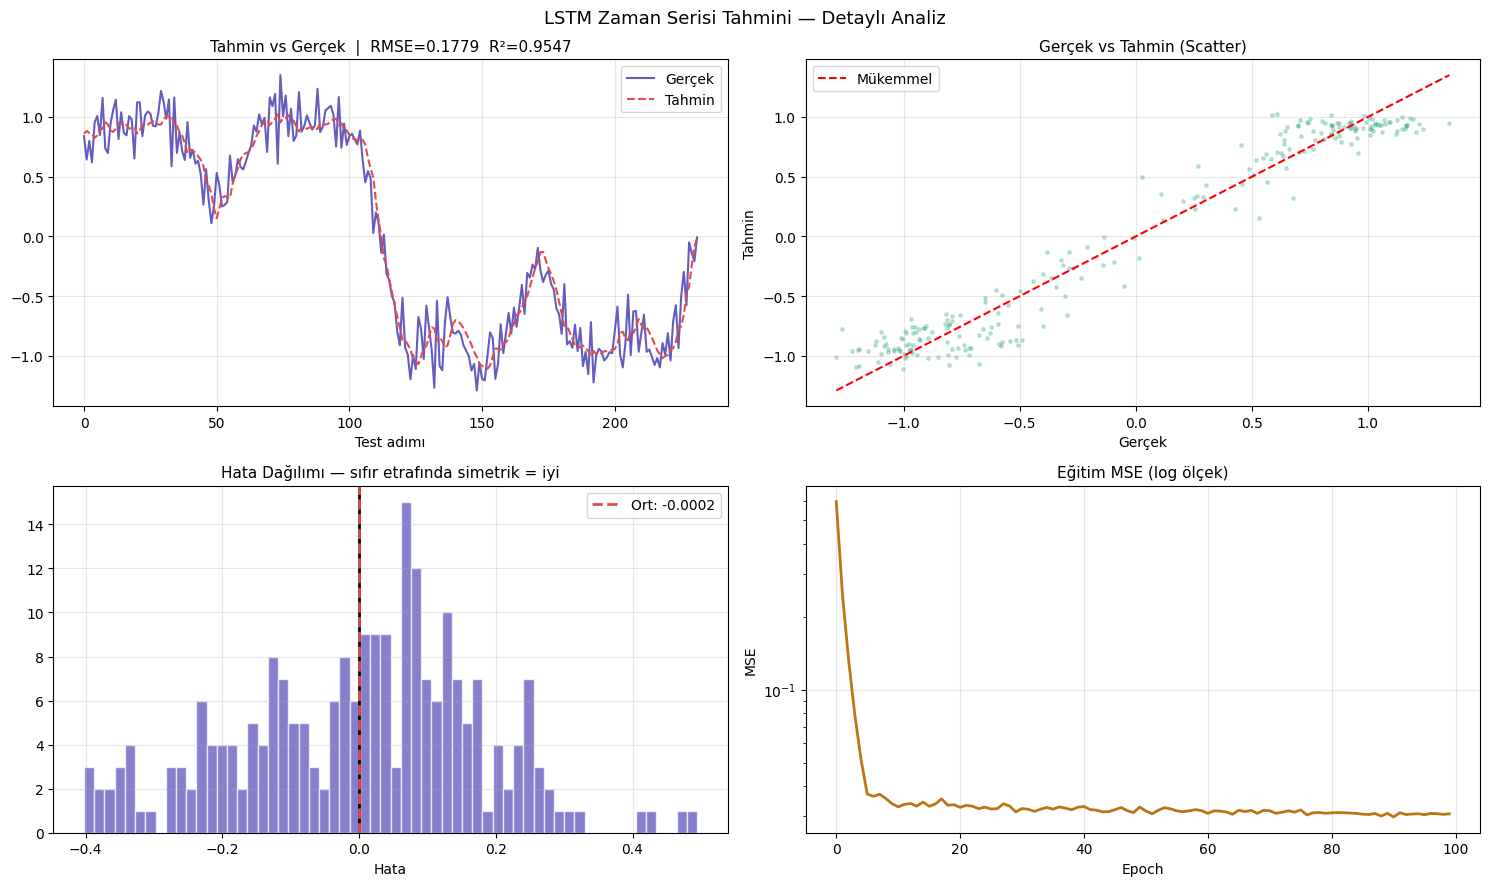

In [13]:
class LSTMForecaster(nn.Module):
    """
    Tek adım ileriye tahmin (regresyon).

    Sınıflandırıcıdan 3 fark:
    1. fc'nin çıktısı 1 (num_classes değil)
    2. Kayıp: MSELoss (CrossEntropy değil)
    3. Son aktivasyon yok (ham değer tahmin ediyoruz)
    """
    def __init__(self, hidden=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = 1,         # tek özellik: serinin kendisi
            hidden_size = hidden,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0,
        )
        # nn.Sequential: katmanları sırayla zincirler — tek bir blok gibi davranır
        # hidden → 32: ara temsil (daha iyi öğrenme kapasitesi)
        # ReLU: negatif değerleri sıfırla → tanh'dan daha hızlı yakınsama
        # 32 → 1: tek skaler çıktı (tahmin edilen değer)
        self.fc = nn.Sequential(
            nn.Linear(hidden, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        """
        x : (batch, window, 1)
        →  (batch,) tek sayı tahmin
        """
        _, (h, _) = self.lstm(x)
        out = self.fc(h[-1])       # (batch, 1)
        return out.squeeze(-1)     # (batch,) — gereksiz boyutu kaldır


torch.manual_seed(0)
forecaster = LSTMForecaster(hidden=64, num_layers=2)

# MSELoss: (tahmin - gerçek)² ortalaması — regresyon standardı
crit_f = nn.MSELoss()
opt_f  = optim.Adam(forecaster.parameters(), lr=1e-3)

# CosineAnnealingLR: lr'yi kosinüs eğrisine göre azaltır
# T_max epoch sonunda minimum'a ulaşır → sonra tekrar artabilir
# StepLR'den farkı: keskin düşüş değil, yumuşak kosinüs eğrisi
sch_f  = optim.lr_scheduler.CosineAnnealingLR(opt_f, T_max=100)

EPOCHS_F, BATCH_F = 100, 64
losses_f = []

print(f"{'Epoch':>6}  {'MSE':>12}  {'RMSE':>8}")
print("─" * 30)

for epoch in range(1, EPOCHS_F + 1):
    forecaster.train()

    # Mini-batch: tüm veriyi bir seferde vermek yerine parçalara böl
    # Neden? Büyük veri setinde bellek tasarrufu + daha sık güncelleme
    idx        = torch.randperm(len(X_tr))   # indisleri karıştır
    epoch_loss = 0.0
    n_batches  = 0

    for i in range(0, len(X_tr), BATCH_F):
        b         = idx[i : i + BATCH_F]
        xb, yb    = X_tr[b], y_tr[b]
        opt_f.zero_grad()
        pred      = forecaster(xb)
        loss      = crit_f(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(forecaster.parameters(), 1.0)
        opt_f.step()
        epoch_loss += loss.item()
        n_batches  += 1

    sch_f.step()
    avg = epoch_loss / n_batches
    losses_f.append(avg)
    if epoch % 20 == 0:
        print(f"{epoch:>6}  {avg:>12.6f}  {avg**0.5:>8.5f}")

print("\nForecaster eğitimi tamamlandı ✓")


# ── Tahmin ve metrikler ───────────────────────────────────────────────────
forecaster.eval()
with torch.no_grad():
    preds_test = forecaster(X_te).numpy()
actuals = y_te.numpy()

mse  = np.mean((preds_test - actuals) ** 2)
mae  = np.mean(np.abs(preds_test - actuals))
rmse = mse ** 0.5
r2   = 1 - np.sum((actuals - preds_test)**2) / np.sum((actuals - actuals.mean())**2)

print(f"\nTest Metrikleri:")
print(f"  MSE  : {mse:.5f}")
print(f"  MAE  : {mae:.5f}")
print(f"  RMSE : {rmse:.5f}  (seri birimiyle hata)")
print(f"  R²   : {r2:.5f}  (1.0 = mükemmel)")

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

n_show = 250
axes[0,0].plot(actuals[:n_show],     label="Gerçek",  color="#534AB7", lw=1.5, alpha=0.9)
axes[0,0].plot(preds_test[:n_show],  label="Tahmin",  color="#E24B4A", lw=1.5, ls="--")
axes[0,0].set_title(f"Tahmin vs Gerçek  |  RMSE={rmse:.4f}  R²={r2:.4f}", fontsize=11)
axes[0,0].set_xlabel("Test adımı"); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

lim = [min(actuals.min(), preds_test.min()), max(actuals.max(), preds_test.max())]
axes[0,1].scatter(actuals, preds_test, alpha=0.25, s=6, color="#1D9E75")
axes[0,1].plot(lim, lim, "r--", lw=1.5, label="Mükemmel")
axes[0,1].set_title("Gerçek vs Tahmin (Scatter)", fontsize=11)
axes[0,1].set_xlabel("Gerçek"); axes[0,1].set_ylabel("Tahmin")
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

errors = preds_test - actuals
axes[1,0].hist(errors, bins=60, color="#534AB7", alpha=0.7, edgecolor="white")
axes[1,0].axvline(0, color="black", lw=2)
axes[1,0].axvline(errors.mean(), color="#E24B4A", lw=2, ls="--",
                  label=f"Ort: {errors.mean():.4f}")
axes[1,0].set_title("Hata Dağılımı — sıfır etrafında simetrik = iyi", fontsize=11)
axes[1,0].set_xlabel("Hata"); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(losses_f, color="#BA7517", lw=2)
axes[1,1].set_title("Eğitim MSE (log ölçek)", fontsize=11)
axes[1,1].set_xlabel("Epoch"); axes[1,1].set_ylabel("MSE")
axes[1,1].set_yscale("log"); axes[1,1].grid(alpha=0.3)

plt.suptitle("LSTM Zaman Serisi Tahmini — Detaylı Analiz", fontsize=13)
plt.tight_layout()
plt.savefig("/tmp/lstm_forecast_detail.png", dpi=120, bbox_inches="tight")
plt.show()


---
## 🔍 Bölüm 9 — Eğitilmiş Kapıları Okuma

PyTorch ağırlıkları şu şekilde sıralar: **i, f, g, o** (giriş, unutma, aday, çıkış)

```
weight_ih_l0[0*H : 1*H]  → giriş (input)  kapısı ağırlıkları
weight_ih_l0[1*H : 2*H]  → unutma (forget) kapısı ağırlıkları
weight_ih_l0[2*H : 3*H]  → aday (cell)    kapısı ağırlıkları
weight_ih_l0[3*H : 4*H]  → çıkış (output) kapısı ağırlıkları
```


Ağırlık şekilleri (1. katman):
  weight_ih_l0 : (256, 1)  — girdi ağırlıkları (4 kapı × input_size)
  weight_hh_l0 : (256, 64) — gizli ağırlıkları (4 kapı × hidden)
  bias_ih_l0   : (256,)

PyTorch kapı sırası: [i | f | g | o]
  Giriş  i: satır 0:64
  Unutma f: satır 64:128
  Aday   g: satır 128:192
  Çıkış  o: satır 192:256


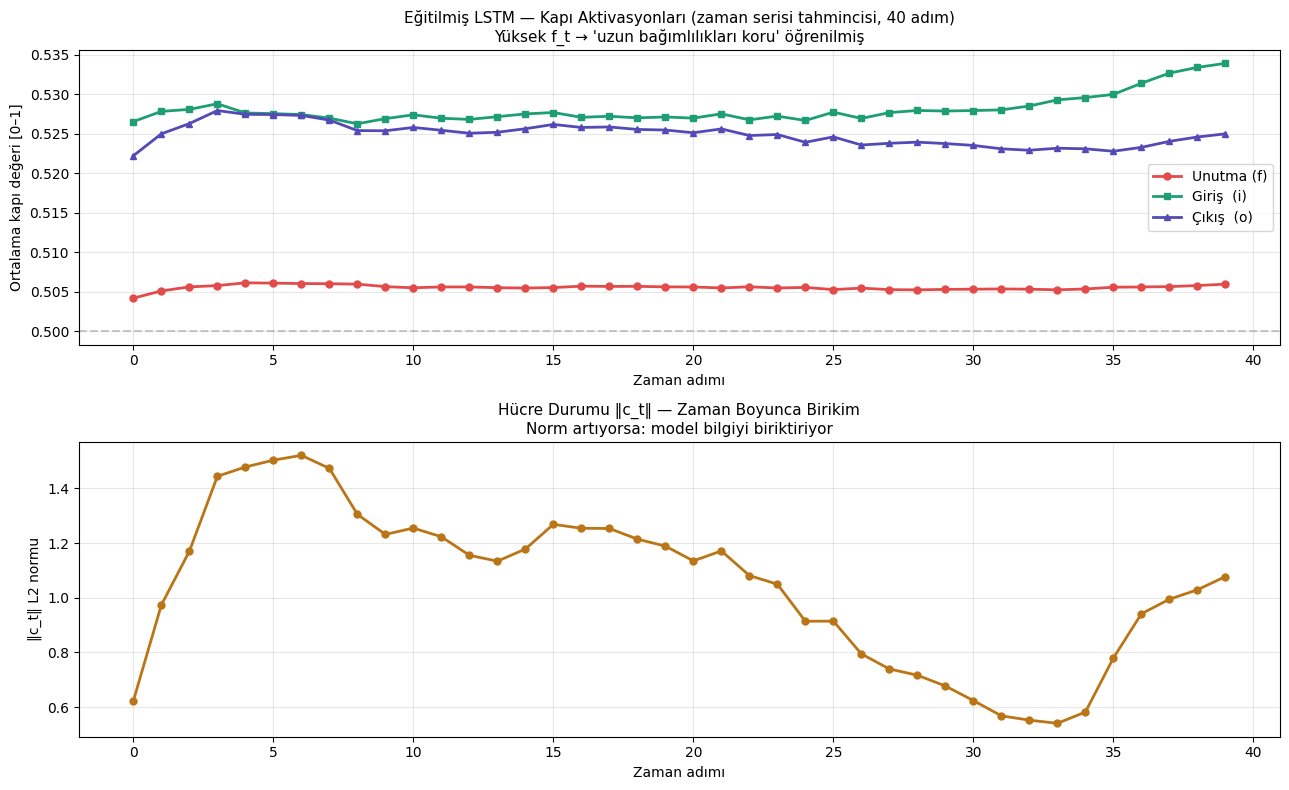

Kapı özetleri:
  f (unutma) ort = 0.506  → hafızayı koruyor
  i (giriş)  ort = 0.528  → aktif öğrenme
  o (çıkış)  ort = 0.525  → yüksek çıktı


In [14]:
forecaster.eval()
lstm_l = forecaster.lstm
H_size = 64

W_ih = lstm_l.weight_ih_l0   # (4*64, 1)
W_hh = lstm_l.weight_hh_l0   # (4*64, 64)
b_ih = lstm_l.bias_ih_l0
b_hh = lstm_l.bias_hh_l0

print("Ağırlık şekilleri (1. katman):")
print(f"  weight_ih_l0 : {tuple(W_ih.shape)}  — girdi ağırlıkları (4 kapı × input_size)")
print(f"  weight_hh_l0 : {tuple(W_hh.shape)} — gizli ağırlıkları (4 kapı × hidden)")
print(f"  bias_ih_l0   : {tuple(b_ih.shape)}")
print()
print("PyTorch kapı sırası: [i | f | g | o]")
print(f"  Giriş  i: satır {0*H_size}:{1*H_size}")
print(f"  Unutma f: satır {1*H_size}:{2*H_size}")
print(f"  Aday   g: satır {2*H_size}:{3*H_size}")
print(f"  Çıkış  o: satır {3*H_size}:{4*H_size}")

# Tek örnek üzerinde adım adım kapı değerleri
sample = X_te[0:1]   # (1, 40, 1)
h = torch.zeros(2, 1, H_size)
c = torch.zeros(2, 1, H_size)

gate_i_tr, gate_f_tr, gate_o_tr, c_norm_tr = [], [], [], []

with torch.no_grad():
    for t in range(WINDOW):
        x_step = sample[:, t:t+1, :]
        _, (h, c) = lstm_l(x_step, (h, c))

        # 1. katman kapılarını elle hesapla
        # W_ih @ x + W_hh @ h + b = tüm kapıların ham değerleri
        raw = W_ih @ x_step[0, 0] + W_hh @ h[0, 0] + b_ih + b_hh

        # PyTorch sırası: i, f, g, o — indeksle ayır
        i_v = torch.sigmoid(raw[0*H_size : 1*H_size]).mean().item()
        f_v = torch.sigmoid(raw[1*H_size : 2*H_size]).mean().item()
        o_v = torch.sigmoid(raw[3*H_size : 4*H_size]).mean().item()

        gate_i_tr.append(i_v)
        gate_f_tr.append(f_v)
        gate_o_tr.append(o_v)
        c_norm_tr.append(c[0].norm().item())

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8))

steps = range(WINDOW)
ax1.plot(steps, gate_f_tr, "o-", label="Unutma (f)", color="#E24B4A", lw=2, ms=5)
ax1.plot(steps, gate_i_tr, "s-", label="Giriş  (i)", color="#1D9E75", lw=2, ms=5)
ax1.plot(steps, gate_o_tr, "^-", label="Çıkış  (o)", color="#534AB7", lw=2, ms=5)
ax1.axhline(0.5, color="gray", ls="--", alpha=0.4)
ax1.set_title("Eğitilmiş LSTM — Kapı Aktivasyonları (zaman serisi tahmincisi, 40 adım)\n"
              "Yüksek f_t → 'uzun bağımlılıkları koru' öğrenilmiş", fontsize=11)
ax1.set_xlabel("Zaman adımı"); ax1.set_ylabel("Ortalama kapı değeri [0–1]")
ax1.legend(fontsize=10); ax1.grid(alpha=0.3)

ax2.plot(steps, c_norm_tr, "o-", color="#BA7517", lw=2, ms=5)
ax2.set_title("Hücre Durumu ‖c_t‖ — Zaman Boyunca Birikim\n"
              "Norm artıyorsa: model bilgiyi biriktiriyor", fontsize=11)
ax2.set_xlabel("Zaman adımı"); ax2.set_ylabel("‖c_t‖ L2 normu"); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/tmp/lstm_trained_gates.png", dpi=120, bbox_inches="tight")
plt.show()

print("Kapı özetleri:")
print(f"  f (unutma) ort = {np.mean(gate_f_tr):.3f}  → "
      f"{'hafızayı koruyor' if np.mean(gate_f_tr)>0.5 else 'hafızayı temizliyor'}")
print(f"  i (giriş)  ort = {np.mean(gate_i_tr):.3f}  → "
      f"{'aktif öğrenme' if np.mean(gate_i_tr)>0.4 else 'az yeni bilgi'}")
print(f"  o (çıkış)  ort = {np.mean(gate_o_tr):.3f}  → "
      f"{'yüksek çıktı' if np.mean(gate_o_tr)>0.5 else 'seçici çıktı'}")


---
## 📋 Bölüm 10 — Özet

### LSTM'nin 6 Formülü

```
f_t = σ( W_f · [h_{t-1}, x_t] + b_f )       ← Unutma: eski hafızadan ne kalsın?
i_t = σ( W_i · [h_{t-1}, x_t] + b_i )       ← Giriş: yeni bilgiden ne eklensin?
g_t = tanh( W_g · [h_{t-1}, x_t] + b_g )    ← Aday: eklenecek ham değer
o_t = σ( W_o · [h_{t-1}, x_t] + b_o )       ← Çıkış: hücreyi ne kadar göster?

c_t = f_t ⊙ c_{t-1}  +  i_t ⊙ g_t           ← Uzun hafıza güncelle
h_t = o_t ⊙ tanh(c_t)                        ← Kısa hafıza güncelle
```

### Gradient Neden Sağlıklı Akar?

```
∂c_t / ∂c_{t-1} = f_t         (sadece tek eleman-eleman çarpım)
f_t ≈ 1 → gradient neredeyse bölünmeden geçer
RNN: her adımda tanh'(.) ≤ 0.25 → 50 adım = 0.25^50 ≈ 10^{-30}
```

### PyTorch'ta Kritik Detaylar

| Satır | Neden önemli? |
|-------|--------------|
| `batch_first=True` | (batch, seq, feat) — daha sezgisel format |
| `output, (h_n, c_n) = lstm(x)` | RNN'den farklı: 2 durum döner |
| `h_n[-1]` | Son katmanın son adımı = dizi özeti |
| `clip_grad_norm_(..., 1.0)` | Patlayan gradient önlemi |
| `model.eval()` | Dropout kapanır — test'te kritik |
| `with torch.no_grad()` | Bellek ve hız tasarrufu — sadece değerlendirmede |

### Ne Zaman LSTM?

```
Kısa dizi  (<20 adım)   → RNN veya GRU yeterli
Orta dizi  (20-100)     → LSTM
Uzun dizi  (100+)       → LSTM veya Transformer
Zaman serisi            → LSTM, TCN (Temporal Conv.)
NLP (modern)            → Transformer (BERT, GPT)
```

### Sonraki Adımlar

- **GRU**: 2 kapı, LSTM kadar güçlü, daha az parametre  
- **Bidirectional LSTM**: hem ileri hem geri yönde tarar  
- **Attention + LSTM**: hangi adıma odaklanılacağını öğrenir  
- **Transformer**: LSTM'nin halefi — paralel eğitim, daha uzun bağımlılık


---
## 🌟 Ekstra: Farklı Bir Veri Setiyle Tekrar (Trend + Mevsimsellik)

Bu bölümde tamamen yeni bir zaman serisi üretiyoruz:
- **Trend:** Zamanla doğrusal olarak artan bir eğilim.
- **Mevsimsellik:** İki farklı periyotta dalgalanma (biri yavaş, biri hızlı).
- **Gürültü:** Rastgele sapmalar.

Önceki bölümlerde tanımladığımız `make_sequences` fonksiyonunu ve `LSTMForecaster` sınıfını kullanarak bu yeni zorlu veriyi modellemeye çalışacağız.

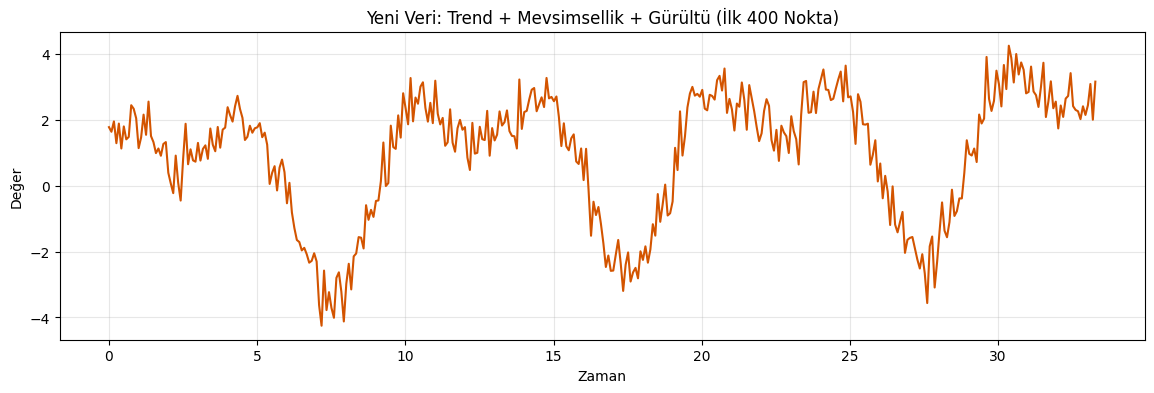

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# Eksik olan fonksiyon ve sınıfları ekliyoruz (bağımsız çalışabilmesi için)
def make_sequences(data, window):
    X_list, y_list = [], []
    for i in range(len(data) - window):
        X_list.append(data[i : i + window])
        y_list.append(data[i + window])
    X_t = torch.tensor(np.array(X_list), dtype=torch.float32).unsqueeze(-1)
    y_t = torch.tensor(np.array(y_list), dtype=torch.float32)
    return X_t, y_t

class LSTMForecaster(nn.Module):
    def __init__(self, hidden=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = 1,
            hidden_size = hidden,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0,
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        out = self.fc(h[-1])
        return out.squeeze(-1)

# 1. YENİ VERİYİ OLUŞTURMA
t_new = np.linspace(0, 100, 1200)
trend = 0.05 * t_new
seasonality = 2 * np.sin(2 * np.pi * t_new / 10) + 1.5 * np.cos(2 * np.pi * t_new / 5)
noise = 0.5 * np.random.randn(len(t_new))

new_series = trend + seasonality + noise

# Görselleştir
plt.figure(figsize=(14, 4))
plt.plot(t_new[:400], new_series[:400], color="#D35400", lw=1.5)
plt.title("Yeni Veri: Trend + Mevsimsellik + Gürültü (İlk 400 Nokta)", fontsize=12)
plt.xlabel("Zaman")
plt.ylabel("Değer")
plt.grid(alpha=0.3)
plt.show()

In [16]:
# 2. VERİ HAZIRLIĞI VE EĞİTİM
WINDOW = 40
X_seq_new, y_seq_new = make_sequences(new_series, WINDOW)

split_new = int(0.8 * len(X_seq_new))
X_tr_new, X_te_new = X_seq_new[:split_new], X_seq_new[split_new:]
y_tr_new, y_te_new = y_seq_new[:split_new], y_seq_new[split_new:]

print(f"Eğitim verisi: {X_tr_new.shape}, Test verisi: {X_te_new.shape}")

# Yeni model örneği oluştur (Önceki bölümde tanımladığımız sınıfı kullanıyoruz)
torch.manual_seed(42)
new_forecaster = LSTMForecaster(hidden=64, num_layers=2)

crit_new = nn.MSELoss()
opt_new = optim.Adam(new_forecaster.parameters(), lr=2e-3)

EPOCHS_NEW = 60
BATCH_NEW = 64

print("\n🚀 Yeni veri üzerinde eğitim başlıyor...")
print(f"{'Epoch':>6}  {'MSE Kaybı':>12}")
print("─" * 22)

for epoch in range(1, EPOCHS_NEW + 1):
    new_forecaster.train()
    idx = torch.randperm(len(X_tr_new))
    epoch_loss = 0.0
    n_batches = 0

    for i in range(0, len(X_tr_new), BATCH_NEW):
        b = idx[i : i + BATCH_NEW]
        xb, yb = X_tr_new[b], y_tr_new[b]

        opt_new.zero_grad()
        pred = new_forecaster(xb)
        loss = crit_new(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(new_forecaster.parameters(), 1.0)
        opt_new.step()

        epoch_loss += loss.item()
        n_batches += 1

    avg_loss = epoch_loss / n_batches
    if epoch % 10 == 0:
        print(f"{epoch:>6}  {avg_loss:>12.6f}")

print("Eğitim tamamlandı! ✓")

Eğitim verisi: torch.Size([928, 40, 1]), Test verisi: torch.Size([232, 40, 1])

🚀 Yeni veri üzerinde eğitim başlıyor...
 Epoch     MSE Kaybı
──────────────────────
    10      0.372323
    20      0.350677
    30      0.350250
    40      0.343853
    50      0.327793
    60      0.342164
Eğitim tamamlandı! ✓



Test Metrikleri:
  RMSE : 0.5624
  R²   : 0.8888


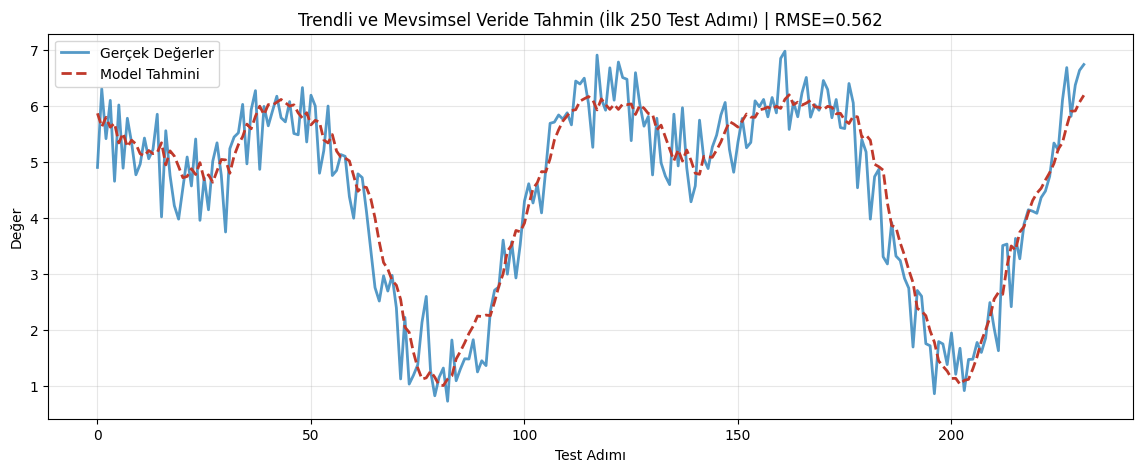

In [17]:
# 3. TEST VE SONUÇLARIN GÖRSELLEŞTİRİLMESİ
new_forecaster.eval()
with torch.no_grad():
    preds_new = new_forecaster(X_te_new).numpy()
actuals_new = y_te_new.numpy()

rmse_new = np.mean((preds_new - actuals_new) ** 2) ** 0.5
r2_new = 1 - np.sum((actuals_new - preds_new)**2) / np.sum((actuals_new - actuals_new.mean())**2)

print(f"\nTest Metrikleri:")
print(f"  RMSE : {rmse_new:.4f}")
print(f"  R²   : {r2_new:.4f}")

plt.figure(figsize=(14, 5))
plt.plot(actuals_new[:250], label="Gerçek Değerler", color="#2980B9", lw=2, alpha=0.8)
plt.plot(preds_new[:250], label="Model Tahmini", color="#C0392B", lw=2, linestyle="--")
plt.title(f"Trendli ve Mevsimsel Veride Tahmin (İlk 250 Test Adımı) | RMSE={rmse_new:.3f}", fontsize=12)
plt.xlabel("Test Adımı")
plt.ylabel("Değer")
plt.legend()
plt.grid(alpha=0.3)
plt.show()